In [10]:
import pandas as pd 
import numpy as np 
import seaborn  as sns

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression


In [3]:
retail_clean = pd.read_csv('retail_clean.csv')

In [11]:
retail_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 779495 entries, 0 to 779494
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Unnamed: 0   779495 non-null  int64         
 1   Invoice      779495 non-null  int64         
 2   StockCode    779495 non-null  object        
 3   Description  779495 non-null  object        
 4   Quantity     779495 non-null  int64         
 5   InvoiceDate  779495 non-null  datetime64[ns]
 6   Price        779495 non-null  float64       
 7   Customer ID  779495 non-null  float64       
 8   Country      779495 non-null  object        
 9   Revenue      779495 non-null  float64       
 10  date         779495 non-null  datetime64[ns]
 11  week         779495 non-null  object        
dtypes: datetime64[ns](2), float64(3), int64(3), object(4)
memory usage: 71.4+ MB


In [12]:
retail_clean.InvoiceDate

0        2009-12-01 07:45:00
1        2009-12-01 07:45:00
2        2009-12-01 07:45:00
3        2009-12-01 07:45:00
4        2009-12-01 07:45:00
                 ...        
779490   2011-12-09 12:50:00
779491   2011-12-09 12:50:00
779492   2011-12-09 12:50:00
779493   2011-12-09 12:50:00
779494   2011-12-09 12:50:00
Name: InvoiceDate, Length: 779495, dtype: datetime64[ns]

In [13]:
retail_clean['InvoiceDate']= pd.to_datetime(retail_clean['InvoiceDate'])

In [14]:
retail_clean['date']= retail_clean['InvoiceDate'].dt.strftime("%Y-%m-%d")

In [15]:
retail_clean['date']=pd.to_datetime(retail_clean['date'])

In [16]:
retail_clean['month']= retail_clean.date.dt.month

In [17]:
retail_clean['year']= retail_clean.date.dt.year

In [19]:
retail_clean['week']= retail_clean.date.dt.week

/var/folders/4s/2k6f8yld43jdpvtdt363thnh0000gn/T/ipykernel_1158/2418076922.py:1: FutureWarning: Series.dt.weekofyear and Series.dt.week have been deprecated. Please use Series.dt.isocalendar().week instead.
  retail_clean['week']= retail_clean.date.dt.week


In [20]:
retail_clean.columns

Index(['Unnamed: 0', 'Invoice', 'StockCode', 'Description', 'Quantity',
       'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Revenue', 'date',
       'week', 'month', 'year'],
      dtype='object')

In [21]:
retail_clean.month.describe()

count    779495.000000
mean          7.417110
std           3.422346
min           1.000000
25%           5.000000
50%           8.000000
75%          11.000000
max          12.000000
Name: month, dtype: float64

In [22]:
time_series=retail_clean.groupby(['week','year']).agg(date= ('date','first'),
        total_revenue=('Revenue',np.sum)).reset_index().sort_values('date')

<AxesSubplot:xlabel='date', ylabel='total_revenue'>

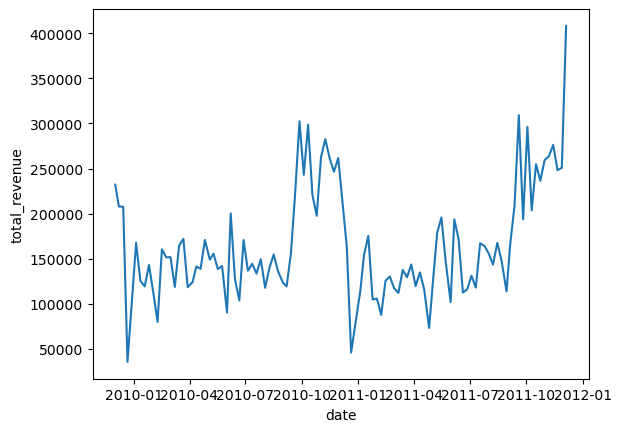

In [24]:
sns.lineplot(x='date', y='total_revenue', data=time_series)

In [25]:
time_series['trend'] = range(time_series.shape[0])

In [26]:
time_series['month'] = time_series['month'].astype('catergory')

KeyError: 'month'